In [5]:
import pandas as pd

df = pd.read_parquet("../outputs/user_anomaly_scores_v1_c001_mf07.parquet")

df.head()

,user_id,avg_stars_given,pct_5_star_reviews,pct_1_star_reviews,review_count,reviews_per_day,account_age_days,num_friends,anomaly_score,is_anomaly,anomaly_rank
0,nnImk681KaRqUVHlSfZjGQ,3.895792,0.388778,0.046092,499,0.069104,7221.0,4214.0,0.155268,1,1
1,6s-g2vFu12OemhiK3FJuOQ,3.653120,0.111756,0.007257,689,0.098288,7010.0,4449.0,0.150034,1,2
2,cufhYFdyrUAt4SWe-m0grQ,3.904139,0.161220,0.006536,459,0.068950,6657.0,6232.0,0.146639,1,3
3,kS1MQHYwIfD0462PE61IBw,3.668293,0.209756,0.009756,205,0.030067,6818.0,2003.0,0.146257,1,4
4,_BcWyKQL16ndpBdggh2kNA,3.542840,0.107981,0.025822,1704,0.260550,6540.0,3708.0,0.145983,1,5


In [6]:
# Count total rows vs unique IDs
total_rows = len(df)
unique_ids = df['user_id'].nunique()

print(f"Total rows in file: {total_rows:,}")
print(f"Unique User IDs:    {unique_ids:,}")

# Check if there are any duplicates
if total_rows == unique_ids:
    print("Verification: Every row represents a unique user.")
else:
    print(f"Warning: There are {total_rows - unique_ids} duplicate user IDs.")

Total rows in file: 1,445,990
Unique User IDs:    1,445,990
Verification: Every row represents a unique user.


In [7]:
# Check the count of NaN values for each column
missing_counts = df.isna().sum()
missing_percentages = (df.isna().mean() * 100).round(6)
# Create a summary table
missing_summary = pd.DataFrame({
    'NaN Count': missing_counts,
    'Percentage (%)': missing_percentages
})

print(missing_summary)

                    NaN Count  Percentage (%)
user_id                     0        0.000000
avg_stars_given             0        0.000000
pct_5_star_reviews          0        0.000000
pct_1_star_reviews          0        0.000000
review_count                0        0.000000
reviews_per_day             0        0.000000
account_age_days            6        0.000415
num_friends                 6        0.000415
anomaly_score               0        0.000000
is_anomaly                  0        0.000000
anomaly_rank                0        0.000000


In [8]:
# Filter for the rows where account_age_days or num_friends is missing
nan_users = df[df['account_age_days'].isna() | df['num_friends'].isna()]

# Display the user_ids and their scores
print(f"Found {len(nan_users)} users with missing data:")
print(nan_users[['user_id', 'review_count', 'account_age_days', 'anomaly_score']])

# List of the IDs
list_of_ids = nan_users['user_id'].tolist()
print("\nUser IDs for manual checking:")
print(list_of_ids)

Found 6 users with missing data:
                        user_id  review_count  account_age_days  anomaly_score
461095   MaengE6zJ6k_d5e6nwnVaA             1               NaN      -0.174910
847521   lzpM_Vf2rKA4ivGtAIOH4w             2               NaN      -0.222019
1050742  5iBVQ3OeK8lV4Z_4PXc1Xw             1               NaN      -0.242400
1230815  5XiPz5mJK_RtJQVkXIqxYg             1               NaN      -0.259112
1230816  I6tb6vPxJ8Tct79JgqIDrQ             1               NaN      -0.259112
1230817  I200IyE9DCxJvvof2wnO6A             1               NaN      -0.259112

User IDs for manual checking:
['MaengE6zJ6k_d5e6nwnVaA', 'lzpM_Vf2rKA4ivGtAIOH4w', '5iBVQ3OeK8lV4Z_4PXc1Xw', '5XiPz5mJK_RtJQVkXIqxYg', 'I6tb6vPxJ8Tct79JgqIDrQ', 'I200IyE9DCxJvvof2wnO6A']


In [9]:
# Showing which is an anomaly
df[df["is_anomaly"] == 1].head(20)

,user_id,avg_stars_given,pct_5_star_reviews,pct_1_star_reviews,review_count,reviews_per_day,account_age_days,num_friends,anomaly_score,is_anomaly,anomaly_rank
0,nnImk681KaRqUVHlSfZjGQ,3.895792,0.388778,0.046092,499,0.069104,7221.0,4214.0,0.155268,1,1
1,6s-g2vFu12OemhiK3FJuOQ,3.653120,0.111756,0.007257,689,0.098288,7010.0,4449.0,0.150034,1,2
2,cufhYFdyrUAt4SWe-m0grQ,3.904139,0.161220,0.006536,459,0.068950,6657.0,6232.0,0.146639,1,3
3,kS1MQHYwIfD0462PE61IBw,3.668293,0.209756,0.009756,205,0.030067,6818.0,2003.0,0.146257,1,4
4,_BcWyKQL16ndpBdggh2kNA,3.542840,0.107981,0.025822,1704,0.260550,6540.0,3708.0,0.145983,1,5
5,y8aWXOimQ9ZgUgZ6q--nCQ,3.868996,0.344978,0.056769,229,0.033956,6744.0,1716.0,0.144661,1,6
6,nnwBdqGHIAJQ5QX9lHOtrQ,2.781955,0.015038,0.045113,133,0.020027,6641.0,2099.0,0.143751,1,7
7,bJ5FtCtZX3ZZacz2_2PJjA,4.069281,0.326797,0.011765,765,0.111500,6861.0,1538.0,0.143312,1,8
8,Ase_kJIYuT6yOsqqVPuWUA,3.526515,0.219697,0.053030,264,0.041089,6425.0,1793.0,0.143182,1,9
9,KDewJBJknfWvQyHHFNbfdg,4.149038,0.379808,0.009615,208,0.030842,6744.0,3964.0,0.142737,1,10


In [10]:
df = df[df['review_count'] >= 5]
df[df["is_anomaly"] == 1].head(20)

,user_id,avg_stars_given,pct_5_star_reviews,pct_1_star_reviews,review_count,reviews_per_day,account_age_days,num_friends,anomaly_score,is_anomaly,anomaly_rank
0,nnImk681KaRqUVHlSfZjGQ,3.895792,0.388778,0.046092,499,0.069104,7221.0,4214.0,0.155268,1,1
1,6s-g2vFu12OemhiK3FJuOQ,3.653120,0.111756,0.007257,689,0.098288,7010.0,4449.0,0.150034,1,2
2,cufhYFdyrUAt4SWe-m0grQ,3.904139,0.161220,0.006536,459,0.068950,6657.0,6232.0,0.146639,1,3
3,kS1MQHYwIfD0462PE61IBw,3.668293,0.209756,0.009756,205,0.030067,6818.0,2003.0,0.146257,1,4
4,_BcWyKQL16ndpBdggh2kNA,3.542840,0.107981,0.025822,1704,0.260550,6540.0,3708.0,0.145983,1,5
5,y8aWXOimQ9ZgUgZ6q--nCQ,3.868996,0.344978,0.056769,229,0.033956,6744.0,1716.0,0.144661,1,6
6,nnwBdqGHIAJQ5QX9lHOtrQ,2.781955,0.015038,0.045113,133,0.020027,6641.0,2099.0,0.143751,1,7
7,bJ5FtCtZX3ZZacz2_2PJjA,4.069281,0.326797,0.011765,765,0.111500,6861.0,1538.0,0.143312,1,8
8,Ase_kJIYuT6yOsqqVPuWUA,3.526515,0.219697,0.053030,264,0.041089,6425.0,1793.0,0.143182,1,9
9,KDewJBJknfWvQyHHFNbfdg,4.149038,0.379808,0.009615,208,0.030842,6744.0,3964.0,0.142737,1,10


In [11]:
df[df["is_anomaly"] == 1][[
    "avg_stars_given",
    "pct_5_star_reviews",
    "review_count",
    "reviews_per_day",
    "num_friends"
]].describe()

,avg_stars_given,pct_5_star_reviews,review_count,reviews_per_day,num_friends
count,14304.000000,14304.000000,14304.000000,14304.000000,14304.000000
mean,3.726966,0.341679,70.165478,0.014796,309.398700
std,0.643192,0.208812,68.073946,0.013417,671.540398
min,1.000000,0.000000,5.000000,0.000636,0.000000
25%,3.460000,0.185613,37.000000,0.007766,33.000000
50%,3.812500,0.302817,53.000000,0.011559,124.000000
75%,4.137424,0.470588,81.000000,0.017361,325.000000
max,5.000000,1.000000,1704.000000,0.269386,12395.000000


In [12]:
import pandas as pd
from pathlib import Path

# Load Phase 2 results (winner sweep output)
PROJECT_ROOT = Path.cwd().parent
ANOMALY_PATH = PROJECT_ROOT / "outputs" / "user_anomaly_scores.parquet"

df = pd.read_parquet(ANOMALY_PATH)

top_anomalies = (
    df[df["is_anomaly"] == 1]
    .sort_values("anomaly_score", ascending=False)
)
# Find users with 0 friends who are in anomaly list
# bots
bots = top_anomalies[
    (top_anomalies['num_friends'] == 0) & 
    (top_anomalies['is_anomaly'] == 1)
].head(10)

# Find "Review Bombers" 
# (Using 0.1 instead of 1.0 based on max of 0.269)
bombers = top_anomalies[
    (top_anomalies['reviews_per_day'] > 0.1) & 
    (top_anomalies['is_anomaly'] == 1)
].head(10)

print("0 Friends + Anomalous (bots)")
display(bots)

print("\n High Velocity + Anomalous (Review Bombers)")
display(bombers)

0 Friends + Anomalous (bots)


,user_id,avg_stars_given,pct_5_star_reviews,pct_1_star_reviews,review_count,reviews_per_day,account_age_days,num_friends,anomaly_score,is_anomaly,anomaly_rank
3039,H6KkiP6dVGqVkSLHtyilzw,1.0,0.0,1.0,2,0.000255,7841.0,0.0,3.384344,1,3040
4343,Bo8K9p_jcYd9mef6sN6A1Q,5.0,1.0,0.0,1,0.000207,4826.0,0.0,2.878401,1,4344
4859,5xetbZnZp443d5YZDM6RXQ,5.0,1.0,0.0,1,0.000230,4339.0,0.0,2.750518,1,4860
4886,2bmaKxTnueY_xavuk_pVww,1.0,0.0,1.0,1,0.000304,3285.0,0.0,2.745989,1,4887
4894,breCTQQ1o_19kOHhOxJVBg,5.0,1.0,0.0,1,0.000202,4956.0,0.0,2.744737,1,4895
5053,VrHog4O-4IL7bW5hXKPz3Q,5.0,1.0,0.0,1,0.000295,3395.0,0.0,2.712981,1,5054
5087,_MdHgoxl1HRSk4tMHv2WRA,5.0,1.0,0.0,1,0.000280,3575.0,0.0,2.708243,1,5088
5114,fUnvKl0Cpoys-ISYH36KFw,4.0,0.0,0.0,1,0.000127,7862.0,0.0,2.703599,1,5115
5120,tCqyfFp9aPv3KuLwRnATrg,4.0,0.0,0.0,1,0.000127,7862.0,0.0,2.702934,1,5121
5165,hpzBhu442zZMGaARnucwbQ,1.0,0.0,1.0,2,0.000273,7313.0,0.0,2.695965,1,5166



 High Velocity + Anomalous (Review Bombers)


,user_id,avg_stars_given,pct_5_star_reviews,pct_1_star_reviews,review_count,reviews_per_day,account_age_days,num_friends,anomaly_score,is_anomaly,anomaly_rank
130,_BcWyKQL16ndpBdggh2kNA,3.542840,0.107981,0.025822,1704,0.260550,6540.0,3708.0,6.796123,1,131
627,-G7Zkl1wIWBBmD0KRy_sCw,3.589823,0.147263,0.017733,1297,0.265888,4878.0,1787.0,5.455094,1,628
1409,fr1Hz2acAb3OaL3l6DyKNg,3.954710,0.214674,0.002717,1104,0.252747,4368.0,825.0,4.718800,1,1410
1643,vmUqcqMjlWoBM6qfmUXgyQ,4.586630,0.626194,0.004093,733,0.269386,2721.0,137.0,4.473360,1,1644
2110,1HM81n6n4iPIFU5d2Lokhw,2.977169,0.027397,0.029224,1095,0.203343,5385.0,482.0,4.027764,1,2111
2215,ET8n-r7glWYqZhuR6GcdNw,3.971154,0.298951,0.006119,1144,0.173281,6602.0,5958.0,3.926454,1,2216
2493,wXdbkFZsfDR7utJvbWElyA,4.173807,0.291310,0.000000,817,0.226065,3614.0,727.0,3.711819,1,2494
3154,bYENop4BuQepBjM1-BI3fA,3.803445,0.191489,0.013171,987,0.171981,5739.0,1214.0,3.325820,1,3155
3212,Xw7ZjaGfr0WNVt6s_5KZfA,4.051493,0.330587,0.004119,971,0.173300,5603.0,1257.0,3.292785,1,3213
3536,ouODopBKF3AqfCkuQEnrDg,3.571130,0.116109,0.026151,956,0.163140,5860.0,1141.0,3.132084,1,3537


In [13]:
# all anomalies Check
anomalies = df[df["is_anomaly"] == 1]

print("all anomalies:", len(anomalies))
print("zero-friend anomalies (all):", ((anomalies["num_friends"] == 0)).sum())

# top 500 anomalies only
top_anomalies = anomalies.sort_values("anomaly_score", ascending=False).head(500)
print("zero-friend anomalies (top 500):", ((top_anomalies["num_friends"] == 0)).sum())

all anomalies: 14096
zero-friend anomalies (all): 1147
zero-friend anomalies (top 500): 0


In [14]:
# Calculate correlation between all numeric columns
correlation_matrix = df[["anomaly_score", "num_friends", "reviews_per_day", "review_count"]].corr()

# Specifically look at the relationship with anomaly_score
print("Correlation with Anomaly Score:")
print(correlation_matrix["anomaly_score"].sort_values(ascending=False))

Correlation with Anomaly Score:
anomaly_score      1.000000
reviews_per_day    0.024009
review_count       0.020124
num_friends       -0.002457
Name: anomaly_score, dtype: float64


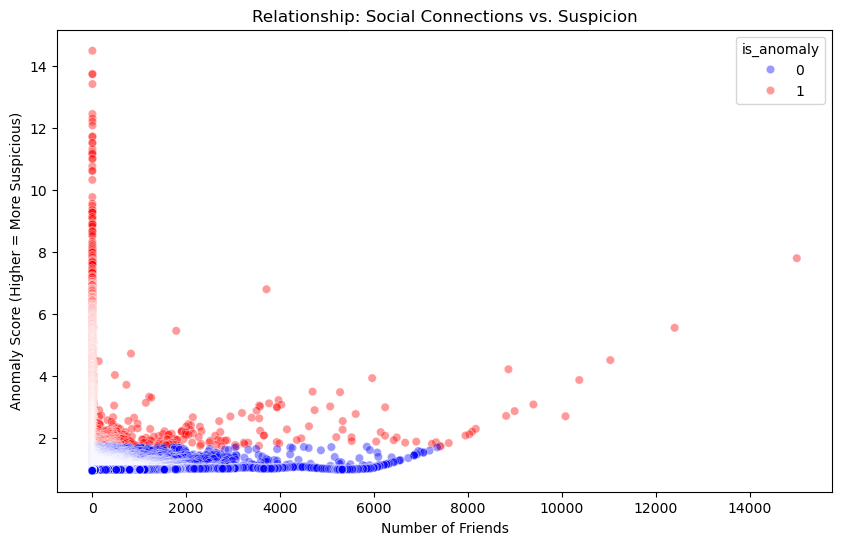

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Use a scatter plot to see where the anomalies (red) sit compared to normal users (blue)
sns.scatterplot(
    data=df, 
    x="num_friends", 
    y="anomaly_score", 
    hue="is_anomaly", 
    palette={0: "blue", 1: "red"},
    alpha=0.4
)

plt.title("Relationship: Social Connections vs. Suspicion")
plt.xlabel("Number of Friends")
plt.ylabel("Anomaly Score (Higher = More Suspicious)")
plt.show()

In [16]:
# Filter only for the anomalies identified by your model
anomalies_only = df[df["is_anomaly"] == 1]

# 1. High-rating anomalous users
high_rating_anomalies = (
    anomalies_only[anomalies_only["avg_stars_given"] >= 4.5]
    .sort_values("anomaly_score", ascending=False)
)

# 2. Low-rating anomalous users
low_rating_anomalies = (
    anomalies_only[anomalies_only["avg_stars_given"] <= 1.5]
    .sort_values("anomaly_score", ascending=False)
)

print(f"Found {len(high_rating_anomalies)} high-rating anomalous users")
print(f"Found {len(low_rating_anomalies)} low-rating anomalous users")

# Display a preview for case_studies.md
print("\n--- HIGH-RATING ANOMALOUS USERS PREVIEW ---")
display(
    high_rating_anomalies[
        ["user_id", "avg_stars_given", "reviews_per_day", "num_friends"]
    ].head(5)
)

print("\n--- LOW-RATING ANOMALOUS USERS PREVIEW ---")
display(
    low_rating_anomalies[
        ["user_id", "avg_stars_given", "reviews_per_day", "num_friends"]
    ].head(5)
)

Found 4482 high-rating anomalous users
Found 3054 low-rating anomalous users

--- HIGH-RATING ANOMALOUS USERS PREVIEW ---


,user_id,avg_stars_given,reviews_per_day,num_friends
0,lzpM_Vf2rKA4ivGtAIOH4w,4.5,0.000000,NaN
1,I200IyE9DCxJvvof2wnO6A,5.0,0.000000,NaN
2,5XiPz5mJK_RtJQVkXIqxYg,5.0,0.000000,NaN
3,I6tb6vPxJ8Tct79JgqIDrQ,5.0,0.000000,NaN
22,GRdNuft9RPWPFSFs-l_Kqg,5.0,0.000641,4.0



--- LOW-RATING ANOMALOUS USERS PREVIEW ---


,user_id,avg_stars_given,reviews_per_day,num_friends
4,MaengE6zJ6k_d5e6nwnVaA,1.0,0.000000,NaN
6,smQhOdnsYN96ITLdbPOTbA,1.0,0.000641,3.0
7,N5pqjUO2NRHDC1IaFU6VBQ,1.0,0.000636,5.0
8,9INW_olEDWZE5fYbvCIe1g,1.0,0.000636,3.0
9,rpzflRzythpFuQiKHWKGag,1.0,0.000641,4.0


In [17]:
# If reviews aren't loaded, need to load them:
# reviews_df = pd.read_parquet("../data/raw/reviews.parquet")

# 1. Get the list of IDs for your top 100 anomalies
top_anomaly_ids = top_anomalies['user_id'].head(100).tolist()

# 2. Filter reviews to see which businesses were reviewed by these specific users
# target_businesses = reviews_df[reviews_df['user_id'].isin(top_anomaly_ids)]

# 3. Find businesses with the most "Anomalous" reviews
# suspicious_biz = target_businesses.groupby('business_id').size().sort_values(ascending=False)
# print("Businesses with the most hits from anomalous users:")
# print(suspicious_biz.head(10))

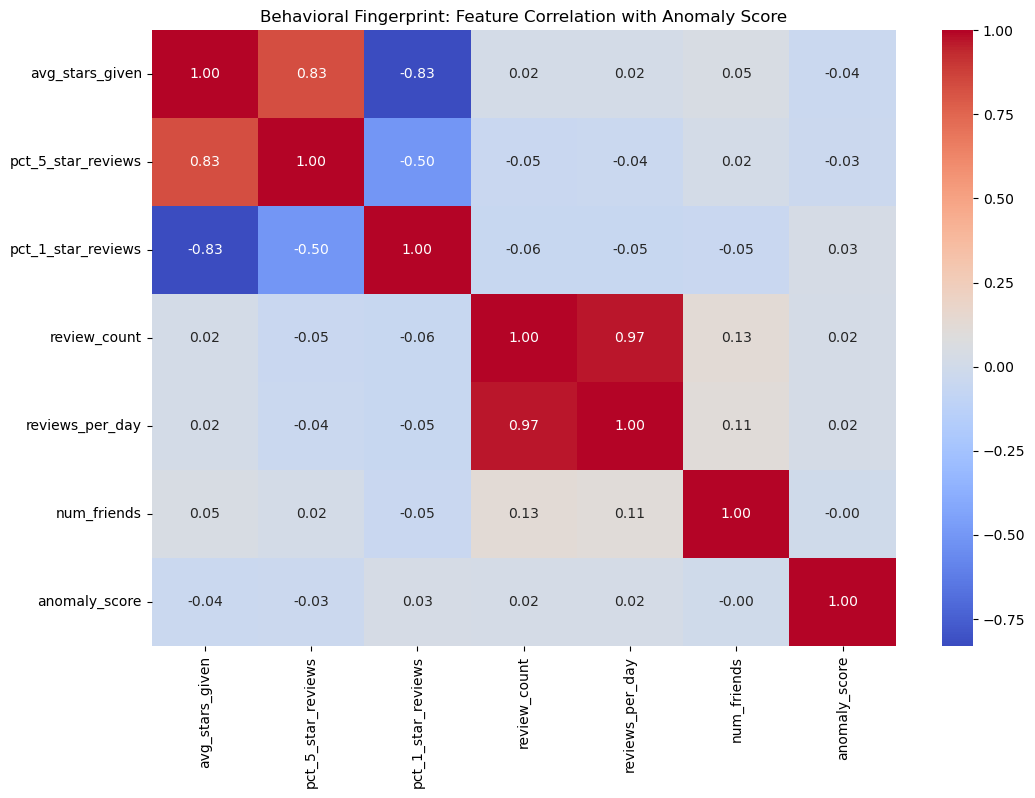

In [18]:
# Features used in your model
features = ["avg_stars_given", "pct_5_star_reviews", "pct_1_star_reviews", 
            "review_count", "reviews_per_day", "num_friends", "anomaly_score"]

plt.figure(figsize=(12, 8))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Behavioral Fingerprint: Feature Correlation with Anomaly Score")
plt.show()

In [19]:
#  top 5 users ranked as most anomalous, along with key behavioral features
df[df["anomaly_rank"] <= 5][["user_id", "review_count", "reviews_per_day", "num_friends", "anomaly_score"]]

,user_id,review_count,reviews_per_day,num_friends,anomaly_score
0,lzpM_Vf2rKA4ivGtAIOH4w,2,0.0,NaN,157.856173
1,I200IyE9DCxJvvof2wnO6A,1,0.0,NaN,105.983792
2,5XiPz5mJK_RtJQVkXIqxYg,1,0.0,NaN,104.751203
3,I6tb6vPxJ8Tct79JgqIDrQ,1,0.0,NaN,104.631514
4,MaengE6zJ6k_d5e6nwnVaA,1,0.0,NaN,100.226588


In [20]:
# Looking for extreme suspicious behavior
# Finds users who: are flagged as anomalies AND give almost all 5-star OR all 1-star reviews
suspicious_extreme = df[
    (df["is_anomaly"] == 1) &
    (
        (df["pct_5_star_reviews"] > 0.95) |
        (df["pct_1_star_reviews"] > 0.95)
    )
]

suspicious_extreme = suspicious_extreme.sort_values("anomaly_score", ascending=False)
suspicious_extreme.head(10)

,user_id,avg_stars_given,pct_5_star_reviews,pct_1_star_reviews,review_count,reviews_per_day,account_age_days,num_friends,anomaly_score,is_anomaly,anomaly_rank
1,I200IyE9DCxJvvof2wnO6A,5.0,1.0,0.0,1,0.000000,NaN,NaN,105.983792,1,2
2,5XiPz5mJK_RtJQVkXIqxYg,5.0,1.0,0.0,1,0.000000,NaN,NaN,104.751203,1,3
3,I6tb6vPxJ8Tct79JgqIDrQ,5.0,1.0,0.0,1,0.000000,NaN,NaN,104.631514,1,4
4,MaengE6zJ6k_d5e6nwnVaA,1.0,0.0,1.0,1,0.000000,NaN,NaN,100.226588,1,5
6,smQhOdnsYN96ITLdbPOTbA,1.0,0.0,1.0,1,0.000641,1561.0,3.0,14.497890,1,7
7,N5pqjUO2NRHDC1IaFU6VBQ,1.0,0.0,1.0,1,0.000636,1573.0,5.0,13.753170,1,8
8,9INW_olEDWZE5fYbvCIe1g,1.0,0.0,1.0,1,0.000636,1573.0,3.0,13.735780,1,9
9,rpzflRzythpFuQiKHWKGag,1.0,0.0,1.0,1,0.000641,1560.0,4.0,13.422731,1,10
10,BA--rwg1uaesYJ10Iv6AZw,1.0,0.0,1.0,1,0.000636,1573.0,3.0,12.455516,1,11
11,hZ45Lrvmq4Nd0NarRzYXqw,1.0,0.0,1.0,1,0.000639,1564.0,5.0,12.316226,1,12


In [21]:
suspicious_extreme[
    ["user_id", "avg_stars_given", "reviews_per_day", "review_count", "num_friends"]
].head(10)

,user_id,avg_stars_given,reviews_per_day,review_count,num_friends
1,I200IyE9DCxJvvof2wnO6A,5.0,0.000000,1,NaN
2,5XiPz5mJK_RtJQVkXIqxYg,5.0,0.000000,1,NaN
3,I6tb6vPxJ8Tct79JgqIDrQ,5.0,0.000000,1,NaN
4,MaengE6zJ6k_d5e6nwnVaA,1.0,0.000000,1,NaN
6,smQhOdnsYN96ITLdbPOTbA,1.0,0.000641,1,3.0
7,N5pqjUO2NRHDC1IaFU6VBQ,1.0,0.000636,1,5.0
8,9INW_olEDWZE5fYbvCIe1g,1.0,0.000636,1,3.0
9,rpzflRzythpFuQiKHWKGag,1.0,0.000641,1,4.0
10,BA--rwg1uaesYJ10Iv6AZw,1.0,0.000636,1,3.0
11,hZ45Lrvmq4Nd0NarRzYXqw,1.0,0.000639,1,5.0
